# Task 1: Character-Level GPT on TinyStories

In this notebook I build a small decoder-only Transformer (a GPT) by hand in PyTorch. It reads
characters from the TinyStories dataset, learns to predict the next character, and then writes
new text one character at a time.

```text
TinyStories text -> char vocab -> encode to ints -> windows (x, y) -> train/val split
  -> GPT -> cross-entropy -> AdamW + warm-up/cosine -> checkpoints + raw logs
  -> metrics -> generation -> failure analysis
```

What I am allowed to use: `nn.Linear`, `nn.Embedding`, `nn.LayerNorm`, `nn.Dropout`.
What I am not using: `nn.Transformer`, `nn.MultiheadAttention`,
`F.scaled_dot_product_attention`, or any prebuilt attention or HuggingFace model. The attention
math (scores, causal mask, softmax, weighted sum of values) is written out explicitly below.

Every hyperparameter comes from `config.yaml` (or the file named in the `TASK1_CONFIG`
environment variable). Nothing is hard-coded inside a function, and every random operation is
seeded from `SEED`.

## 0) Personal parameters

The first code cell holds my personal course parameters. Only `SEED` applies to this lab, and
it is the single source of randomness for the data split, weight initialization, dropout, batch
sampling and generation.

In [1]:
# Personal parameters (course-assigned). Only SEED is used in this lab.
SEED = 8893

print(f"SEED = {SEED}")

SEED = 8893


### Setup: imports, config, device, seeding

This cell loads the libraries and reads the config. A few choices I made here:

- **Config:** `config.yaml` is the single source of hyperparameters. A config file can
  `base:` another one and only override a few keys, which is how the smoke-test config stays tiny.
  If the YAML `seed` disagrees with `SEED`, I overwrite it with `SEED` so the notebook always uses
  my personal seed.
- **Device:** `auto` picks CUDA when it exists and CPU otherwise.
- **Precision:** fp16 autocast with a `GradScaler` is switched on only when CUDA is available. I
  never use bf16 because a T4 does not support it natively.
- **`set_seed`:** seeds Python, NumPy and PyTorch (CPU and CUDA) from `SEED`. I call it again before
  every stage that creates random numbers (model building, sanity tests, training), so each stage
  is reproducible no matter which cells I re-ran before it.

In [2]:
import contextlib
import copy
import csv
import json
import math
import os
import platform
import random
import sys
import time
import urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

try:
    import yaml
except ImportError as e:
    raise ImportError("PyYAML is required to read the config file (pip install pyyaml).") from e


# ---------------------------------------------------------------- config
CONFIG_PATH = os.environ.get("TASK1_CONFIG", "config.yaml")
CONFIG_OVERRIDES = {}  # optional in-notebook overrides, e.g. {"train": {"epochs": 2}}


def deep_update(base, new):
    out = copy.deepcopy(base)
    for key, value in new.items():
        if isinstance(value, dict) and isinstance(out.get(key), dict):
            out[key] = deep_update(out[key], value)
        else:
            out[key] = copy.deepcopy(value)
    return out


def load_config(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Config file not found: {path} (current folder: {Path.cwd()})")
    with open(path, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)
    base = cfg.pop("base", None)
    if base is not None:
        cfg = deep_update(load_config(path.parent / base), cfg)
    return cfg


cfg = deep_update(load_config(CONFIG_PATH), CONFIG_OVERRIDES)
if cfg.get("seed") != SEED:
    print(f"WARNING: config seed {cfg.get('seed')} != SEED {SEED}. Using SEED.")
cfg["seed"] = SEED

RUN_NAME = cfg["run_name"]
P = {key: Path(value) for key, value in cfg["paths"].items()}
for key in ("data_dir", "processed_dir", "checkpoint_dir", "output_dir", "raw_logs_dir", "manifest_dir"):
    P[key].mkdir(parents=True, exist_ok=True)
P["metrics_csv"].parent.mkdir(parents=True, exist_ok=True)


# ---------------------------------------------------------------- device and precision
def pick_device(name):
    if name == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if name == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("config asks for cuda but CUDA is not available")
    return torch.device(name)


device = pick_device(cfg["device"])
use_amp = bool(cfg["train"]["amp"]) and device.type == "cuda"
AMP_DTYPE = torch.float16  # fp16 only (a T4 has no fast bf16)


def amp_ctx():
    """fp16 autocast on CUDA when enabled, otherwise a no-op context."""
    if use_amp:
        return torch.autocast(device_type=device.type, dtype=AMP_DTYPE)
    return contextlib.nullcontext()


def make_scaler(enabled):
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def sync():
    if device.type == "cuda":
        torch.cuda.synchronize()


def torch_load(path):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


# ---------------------------------------------------------------- seeding
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed(SEED)

print(f"config: {CONFIG_PATH} | run_name: {RUN_NAME}")
print(f"device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))
print(f"fp16 autocast + GradScaler: {use_amp}")
print(f"torch {torch.__version__}, numpy {np.__version__}")

config: config.yaml | run_name: main
device: cuda (NVIDIA GeForce RTX 4090)
fp16 autocast + GradScaler: True
torch 2.14.1+cu130, numpy 2.5.3


## 1) Data: TinyStories, vocabulary, windows, split, loaders

### 1.1 Loading the text and making a contiguous train/validation split

The raw TinyStories file separates stories with the literal marker `<|endoftext|>`. I split on that
marker so I know where every story starts and ends, then join the stories back together with a
blank line. The only whitespace I strip is the whitespace around the marker (controlled by
`strip_story_edges`). I never lowercase anything and never touch punctuation inside a story, so
the model has to learn capitalization and punctuation itself.

The brief says 100K train / 10K validation without saying what the unit is, so the split unit is a
config switch:

- `chars`: 100K characters of training text and 10K characters of validation text.
- `sequences`: 100K training windows of `block_size` characters and 10K validation windows.

How the split works, in both cases:

1. A random starting story is chosen using `SEED`, so my subset is reproducible and different from
   a teammate who uses a different seed.
2. The training text is the first `train` characters from that point, a **contiguous chunk**.
3. The validation text starts at the **next story boundary** after the training chunk. The story that
   straddles the boundary is dropped, so no validation story is ever partly seen in training.

I also save the encoded ids, the vocabulary and the split details to `data_processed/`.

In [3]:
dcfg = cfg["data"]
BLOCK_SIZE = dcfg["block_size"]


def load_raw_text(data_dir, file_name, url):
    path = data_dir / file_name
    if not path.exists():
        print(f"Raw file not found. Downloading from {url}")
        tmp_path = path.with_name(path.name + ".part")
        urllib.request.urlretrieve(url, tmp_path)
        tmp_path.replace(path)
    with open(path, "r", encoding="utf-8") as f:
        return f.read()


def split_into_stories(raw, delimiter, strip_edges):
    parts = raw.split(delimiter)
    if strip_edges:
        parts = [p.strip() for p in parts]
    return [p for p in parts if len(p.strip()) > 0]


def chars_needed(unit, size, block_size):
    """How many characters a split of `size` units needs (non-overlapping windows need +1 for the last target)."""
    if unit == "chars":
        return size
    if unit == "sequences":
        return size * block_size + 1
    raise ValueError(f"split_unit must be 'chars' or 'sequences', got {unit!r}")


def contiguous_split(stories, joiner, n_train, n_val, seed):
    """Seeded contiguous train chunk, then validation from the next story boundary."""
    lens = np.array([len(s) for s in stories], dtype=np.int64)
    stride = lens + len(joiner)
    story_starts = np.concatenate([[0], np.cumsum(stride)[:-1]])  # start offset of each story in the full joined text
    total_chars = int(stride.sum()) - len(joiner)
    longest = int(lens.max())

    # leave room for: train chunk + the straddling story that gets dropped + validation chunk
    need = n_train + longest + len(joiner) + n_val
    valid_starts = np.where(total_chars - story_starts >= need)[0]
    if len(valid_starts) == 0:
        raise ValueError("The raw file is too small for this split size. Use a larger raw file or smaller sizes.")

    rng = np.random.default_rng(seed)
    first_story = int(rng.choice(valid_starts))
    sub = joiner.join(stories[first_story:])
    local_starts = story_starts[first_story:] - story_starts[first_story]

    train_text = sub[:n_train]
    k = int(np.searchsorted(local_starts, n_train, side="left"))  # first story that starts at/after the train end
    val_start = int(local_starts[k])
    val_text = sub[val_start:val_start + n_val]

    info = {
        "first_story_index": first_story,
        "n_stories_in_raw_file": len(stories),
        "train_chars": len(train_text),
        "val_chars": len(val_text),
        "val_start_offset_in_chunk": val_start,
        "dropped_chars_between_train_and_val": val_start - n_train,
    }
    return train_text, val_text, info


raw_text = load_raw_text(P["data_dir"], dcfg["raw_file"], dcfg["raw_url"])
stories = split_into_stories(raw_text, dcfg["story_delimiter"], dcfg["strip_story_edges"])
print(f"raw characters: {len(raw_text):,} | stories: {len(stories):,}")

n_train_chars = chars_needed(dcfg["split_unit"], dcfg["train_size"], BLOCK_SIZE)
n_val_chars = chars_needed(dcfg["split_unit"], dcfg["val_size"], BLOCK_SIZE)

train_text, val_text, split_info = contiguous_split(
    stories, dcfg["story_joiner"], n_train_chars, n_val_chars, SEED
)
split_info.update({"split_unit": dcfg["split_unit"], "train_size": dcfg["train_size"],
                   "val_size": dcfg["val_size"], "block_size": BLOCK_SIZE, "seed": SEED})
print(json.dumps(split_info, indent=2))

# Leak check: the start of the validation text must not appear anywhere in the training text.
leak_probe = val_text[:min(200, len(val_text))]
print("validation probe found inside training text (should be False):", leak_probe in train_text)
print("\nfirst 300 training characters:\n" + train_text[:300])

Raw file not found. Downloading from https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStoriesV2-GPT4-valid.txt


raw characters: 22,493,387 | stories: 27,630
{
  "first_story_index": 10030,
  "n_stories_in_raw_file": 27630,
  "train_chars": 12800001,
  "val_chars": 1280001,
  "val_start_offset_in_chunk": 12800471,
  "dropped_chars_between_train_and_val": 470,
  "split_unit": "sequences",
  "train_size": 100000,
  "val_size": 10000,
  "block_size": 128,
  "seed": 8893
}
validation probe found inside training text (should be False): False

first 300 training characters:
One day, a fish named Bob wanted to swim. Bob lived in a tank. The tank was dirty and disgusting. Bob was sad.
Bob's friend, Tim, came to visit. Tim saw the dirty tank. "Ew!" said Tim. "Your tank is disgusting! Let's clean it." But Bob did not want to clean the tank. Bob just wanted to swim.
Bob swa


### 1.2 Character vocabulary, windows and loaders

The model works on integers, so every distinct character in my subset (train plus validation
text) gets an ID. `chars` is built from `sorted(set(...))`, so the order is deterministic.
`char_to_idx` turns characters into IDs and `idx_to_char` turns IDs back into characters. Nothing is
lowercased or removed.

Next-character windows with `T = block_size`:

```text
x = ids[i : i + T]
y = ids[i + 1 : i + T + 1]      (the same window shifted by one character)
```

Two loaders, for two different jobs:

- **Training:** `RandomWindowSampler` draws `batch_size` random start offsets for every batch. It has
  its own `torch.Generator` seeded from `SEED`, so the batch order is reproducible and can be saved
  and restored when I resume a run.
- **Evaluation:** `fixed_windows` cuts the text into fixed, non-overlapping windows. The same
  windows are used every time, so validation numbers are deterministic and comparable across
  runs. For the training text I use a fixed, evenly spaced subset of windows to measure the
  training loss in eval mode (dropout off).

In [4]:
# ---------------------------------------------------------------- vocabulary
chars = sorted(set(train_text + val_text))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}


def encode(text):
    """str -> list of ints. Raises a clear error for characters outside the vocabulary."""
    missing = sorted({c for c in text if c not in char_to_idx})
    if missing:
        raise ValueError(f"Characters not in the vocabulary: {missing}")
    return [char_to_idx[c] for c in text]


def decode(ids):
    return "".join(idx_to_char[int(i)] for i in ids)


def encode_tensor(text):
    arr = np.fromiter((char_to_idx[c] for c in text), dtype=np.int64, count=len(text))
    return torch.from_numpy(arr)


train_ids = encode_tensor(train_text)
val_ids = encode_tensor(val_text)
print(f"vocab size: {vocab_size}")
print("vocabulary:", repr("".join(chars)))
print(f"train ids: {tuple(train_ids.shape)} | val ids: {tuple(val_ids.shape)}")
assert decode(train_ids[:50].tolist()) == train_text[:50]  # round trip

# ---------------------------------------------------------------- save the processed data
id_dtype = np.uint8 if vocab_size <= 256 else np.uint16
np.save(P["processed_dir"] / "train_ids.npy", train_ids.numpy().astype(id_dtype))
np.save(P["processed_dir"] / "val_ids.npy", val_ids.numpy().astype(id_dtype))
with open(P["processed_dir"] / "vocab.json", "w", encoding="utf-8") as f:
    json.dump({"chars": chars, "char_to_idx": char_to_idx}, f, ensure_ascii=False, indent=1)
with open(P["processed_dir"] / "split_info.json", "w", encoding="utf-8") as f:
    json.dump(split_info, f, indent=1)


# ---------------------------------------------------------------- loaders
class RandomWindowSampler:
    """Random-offset training batches with a seeded, restorable generator."""

    def __init__(self, ids, block_size, batch_size, seed):
        if len(ids) < block_size + 2:
            raise ValueError(f"Need more than block_size + 1 = {block_size + 1} ids, got {len(ids)}")
        self.ids = ids
        self.block_size = block_size
        self.batch_size = batch_size
        self.n_starts = len(ids) - block_size  # valid starts are 0 .. len - block_size - 1
        self.offsets = torch.arange(block_size)
        self.gen = torch.Generator()
        self.gen.manual_seed(seed)

    def next_batch(self):
        starts = torch.randint(0, self.n_starts, (self.batch_size,), generator=self.gen)
        idx = starts[:, None] + self.offsets[None, :]
        return self.ids[idx], self.ids[idx + 1]


def fixed_windows(ids, block_size, max_windows=None):
    """Fixed non-overlapping windows. If max_windows is set, take evenly spaced ones."""
    n_windows = (len(ids) - 1) // block_size
    if n_windows < 1:
        raise ValueError("Not enough ids for even one window")
    which = np.arange(n_windows)
    if max_windows is not None and n_windows > max_windows:
        which = np.unique(np.linspace(0, n_windows - 1, max_windows).astype(np.int64))
    starts = torch.from_numpy(which * block_size)
    idx = starts[:, None] + torch.arange(block_size)[None, :]
    return ids[idx], ids[idx + 1]


def iter_batches(X, Y, batch_size):
    for i in range(0, X.size(0), batch_size):
        yield X[i:i + batch_size], Y[i:i + batch_size]


val_X, val_Y = fixed_windows(val_ids, BLOCK_SIZE)
train_eval_X, train_eval_Y = fixed_windows(train_ids, BLOCK_SIZE, cfg["eval"]["train_eval_windows"])
n_train_windows = (len(train_ids) - 1) // BLOCK_SIZE

print(f"non-overlapping train windows: {n_train_windows:,} | val windows: {val_X.size(0):,} "
      f"| train-eval windows: {train_eval_X.size(0):,}")

# Look at one batch: y must be x shifted by one character.
_demo_sampler = RandomWindowSampler(train_ids, BLOCK_SIZE, 2, SEED)
_xb, _yb = _demo_sampler.next_batch()
print("x batch:", tuple(_xb.shape), "| y batch:", tuple(_yb.shape))
assert torch.equal(_xb[:, 1:], _yb[:, :-1])
print("x[0][:60]:", repr(decode(_xb[0, :60].tolist())))
print("y[0][:60]:", repr(decode(_yb[0, :60].tolist())))

vocab size: 83
vocabulary: '\n !"\',-./012345789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZ`abcdefghijklmnopqrstuvwxyzéñ–—‘’“”…'
train ids: (12800001,) | val ids: (1280001,)
non-overlapping train windows: 100,000 | val windows: 10,000 | train-eval windows: 2,000
x batch: (2, 128) | y batch: (2, 128)
x[0][:60]: ' mouse!\nThe mouse had been caught in a trap and was scared. '
y[0][:60]: 'mouse!\nThe mouse had been caught in a trap and was scared. L'


## 2) Model: a pre-LN decoder-only GPT written by hand

```text
input characters (B, T)
  -> token embedding + learned positional embedding -> dropout
  -> N x [ LayerNorm -> causal multi-head attention -> + residual
           LayerNorm -> feed-forward (GELU)         -> + residual ]
  -> final LayerNorm -> LM head (d_model -> vocab logits)
```

**Attention, written by hand.** One `nn.Linear` produces Q, K and V together, and I reshape the
result into `H` heads of size `d_head = d_model / H`. Then:

1. `scores = Q Kᵀ / sqrt(d_head)`. The scaling keeps the variance of the scores near 1, so the
   softmax does not saturate.
2. A lower-triangular causal mask is stored as a buffer, and `masked_fill(mask == 0, -inf)` hides every
   future position.
3. `softmax` over the last dimension, dropout on the attention weights, then `@ V`.
4. Merge the heads back together and apply the output projection.

I compute the softmax in float32 and cast back, which keeps fp16 training stable.

**Feed-forward:** `Linear(d, d_ff) -> GELU -> Linear(d_ff, d) -> dropout`.

**Initialization:** all `Linear` and `Embedding` weights are `normal(0, init_std)` with biases at zero.
The two projections that write into the residual stream (attention output and the second FFN
linear) use `init_std / sqrt(2N)` instead, so the residual stream does not grow with depth. Weight
tying between the LM head and the token embedding is a config switch (`tie_weights`).

**Position handling:** at every generation step the context is cropped to the last `block_size`
characters, because the learned positional embedding only has `block_size` slots.

In [5]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError(f"d_model ({d_model}) must be divisible by n_heads ({n_heads})")
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)   # one layer produces Q, K and V
        self.proj = nn.Linear(d_model, d_model)      # output projection
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        causal = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer("mask", causal, persistent=False)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)                         # each (B, T, C)
        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)   # (B, H, T, d_head)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_head)   # (B, H, T, T)
        scores = scores.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        weights = F.softmax(scores.float(), dim=-1).to(q.dtype)       # softmax in fp32
        weights = self.attn_drop(weights)

        out = weights @ v                                             # (B, H, T, d_head)
        out = out.transpose(1, 2).contiguous().view(B, T, C)          # merge heads
        return self.resid_drop(self.proj(out))


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        return self.drop(self.fc2(F.gelu(self.fc1(x))))


class Block(nn.Module):
    """Pre-LN transformer block."""

    def __init__(self, d_model, n_heads, d_ff, block_size, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, block_size, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ffn = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


class GPT(nn.Module):
    def __init__(self, vocab_size, block_size, d_model, n_layers, n_heads, d_ff, dropout,
                 tie_weights, init_std):
        super().__init__()
        self.vocab_size = vocab_size
        self.block_size = block_size
        self.init_std = init_std
        self.n_layers = n_layers

        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(block_size, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [Block(d_model, n_heads, d_ff, block_size, dropout) for _ in range(n_layers)]
        )
        self.ln_f = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        if tie_weights:
            self.lm_head.weight = self.tok_emb.weight

        self.apply(self._init_weights)
        # residual-stream output projections: std / sqrt(2N)
        for name, p in self.named_parameters():
            if name.endswith("attn.proj.weight") or name.endswith("ffn.fc2.weight"):
                nn.init.normal_(p, mean=0.0, std=init_std / math.sqrt(2 * n_layers))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=self.init_std)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=self.init_std)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        if T > self.block_size:
            raise ValueError(f"sequence length {T} is longer than block_size {self.block_size}")
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))   # (B, T, C)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)                               # (B, T, vocab)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.float().reshape(-1, logits.size(-1)), targets.reshape(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=None, top_k=None, greedy=False, generator=None):
        """Autoregressive generation. The context is cropped to the last block_size characters."""
        was_training = self.training
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            with amp_ctx():
                logits, _ = self(idx_cond)
            logits = logits[:, -1, :].float()
            if greedy:
                next_id = torch.argmax(logits, dim=-1, keepdim=True)
            else:
                logits = logits / temperature
                if top_k is not None:
                    k = min(top_k, logits.size(-1))
                    kth_value = torch.topk(logits, k).values[:, -1, None]
                    logits = logits.masked_fill(logits < kth_value, float("-inf"))
                probs = F.softmax(logits, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1, generator=generator)
            idx = torch.cat([idx, next_id], dim=1)
        self.train(was_training)
        return idx


def build_model(cfg, vocab_size):
    m = cfg["model"]
    return GPT(
        vocab_size=vocab_size,
        block_size=cfg["data"]["block_size"],
        d_model=m["d_model"],
        n_layers=m["n_layers"],
        n_heads=m["n_heads"],
        d_ff=m["d_ff"],
        dropout=m["dropout"],
        tie_weights=m["tie_weights"],
        init_std=m["init_std"],
    )


def count_params(model):
    return sum(p.numel() for p in model.parameters())


set_seed(SEED)
_probe_model = build_model(cfg, vocab_size)
print(f"parameters with this config: {count_params(_probe_model):,} (tie_weights = {cfg['model']['tie_weights']})")
del _probe_model

parameters with this config: 830,976 (tie_weights = False)


## 3) Sanity tests before I train anything

These checks catch most bugs, so I run them before the real training run. Each test builds its own
fresh, freshly seeded model, so the tests never change the model I train later.

1. **Shapes:** forward hooks print the output shape of each stage in one forward pass, so I can
   compare them with the architecture diagram.
2. **Initial loss:** with small random weights the model knows nothing, so its loss should be close to
   `ln(vocab_size)`, the loss of a uniform guess over the vocabulary.
3. **Causal-mask test:** I change one token in the middle of a window and check that the logits for
   every earlier position are unchanged (while the logits from that position onward do change). If
   the mask leaked the future, earlier logits would move.
4. **Overfit one small batch:** with dropout off, the model should be able to memorize a tiny batch
   and push the loss close to zero. If it cannot, there is a bug somewhere in the model or the
   training step.

The tolerances and step counts come from the `sanity` section of the config. The causal-mask test is
an `assert`, because a failure there means the model is invalid. The other tests print PASS/FAIL.

In [6]:
def trace_shapes(cfg, vocab_size):
    set_seed(SEED)
    model = build_model(cfg, vocab_size).to(device).eval()
    x = val_X[:2].to(device)
    stages = {
        "tok_emb": model.tok_emb,
        "pos_emb": model.pos_emb,
        "drop (emb)": model.drop,
        "blocks[0].ln1": model.blocks[0].ln1,
        "blocks[0].attn": model.blocks[0].attn,
        "blocks[0].ln2": model.blocks[0].ln2,
        "blocks[0].ffn": model.blocks[0].ffn,
        "blocks[-1] (output)": model.blocks[-1],
        "ln_f": model.ln_f,
        "lm_head": model.lm_head,
    }
    handles = []
    for name, module in stages.items():
        def hook(mod, inputs, output, name=name):
            print(f"  {name:<22} -> {tuple(output.shape)}")
        handles.append(module.register_forward_hook(hook))
    print(f"input x: {tuple(x.shape)}")
    try:
        with torch.no_grad():
            logits, _ = model(x)
    finally:
        for h in handles:
            h.remove()
    d_model = cfg["model"]["d_model"]
    ok = tuple(logits.shape) == (x.size(0), x.size(1), vocab_size)
    print(f"logits: {tuple(logits.shape)} (expected (B, T, vocab) with vocab = {vocab_size}, d_model = {d_model})")
    print("shape trace:", "PASS" if ok else "FAIL")
    return ok


@torch.no_grad()
def test_initial_loss(cfg, vocab_size):
    s = cfg["sanity"]
    set_seed(SEED)
    model = build_model(cfg, vocab_size).to(device).eval()
    x = val_X[:s["init_batch_size"]].to(device)
    y = val_Y[:s["init_batch_size"]].to(device)
    _, loss = model(x, y)
    expected = math.log(vocab_size)
    ok = abs(loss.item() - expected) <= s["init_loss_tol"]
    print(f"initial loss {loss.item():.4f} vs ln(vocab) {expected:.4f} (tolerance {s['init_loss_tol']}):",
          "PASS" if ok else "FAIL")
    return ok


@torch.no_grad()
def test_causal_mask(cfg, vocab_size):
    s = cfg["sanity"]
    set_seed(SEED)
    model = build_model(cfg, vocab_size).to(device).eval()   # eval: dropout off, fp32 (no autocast)
    x = val_X[:2].to(device)
    t = max(1, int(x.size(1) * s["causal_position_frac"]))
    x_changed = x.clone()
    x_changed[:, t] = (x_changed[:, t] + 1) % vocab_size     # change one token in the 'future' of positions < t
    logits_a, _ = model(x)
    logits_b, _ = model(x_changed)
    before = (logits_a[:, :t] - logits_b[:, :t]).abs().max().item()
    after = (logits_a[:, t:] - logits_b[:, t:]).abs().max().item()
    print(f"changed position {t}: max |diff| at earlier positions = {before:.3e}, from position {t} onward = {after:.3e}")
    assert before <= s["causal_atol"], "Causal mask leaks: logits before the changed token moved"
    assert after > s["causal_atol"], "Test is not informative: changing the token did not change later logits"
    print("causal mask test: PASS")
    return True


def test_overfit_one_batch(cfg, vocab_size):
    s = cfg["sanity"]
    set_seed(SEED)
    model = build_model(cfg, vocab_size).to(device)
    model.eval()  # dropout off, so memorizing the batch is possible; gradients still flow
    x = train_eval_X[:s["overfit_batch_size"]].to(device)
    y = train_eval_Y[:s["overfit_batch_size"]].to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=s["overfit_lr"], betas=tuple(cfg["train"]["betas"]),
                            weight_decay=0.0)
    last_loss = float("nan")
    for step in range(1, s["overfit_steps"] + 1):
        _, loss = model(x, y)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["train"]["grad_clip"])
        opt.step()
        last_loss = loss.item()
        if step == 1 or step % s["overfit_print_every"] == 0:
            print(f"  overfit step {step:>4}/{s['overfit_steps']}  loss {last_loss:.4f}")
    ok = last_loss <= s["overfit_pass_loss"]
    print(f"overfit one batch: final loss {last_loss:.4f} (target <= {s['overfit_pass_loss']}):",
          "PASS" if ok else "FAIL")
    return ok


def run_sanity_tests(cfg, vocab_size):
    results = {}
    print("== 1) shapes ==")
    results["shapes"] = trace_shapes(cfg, vocab_size)
    print("\n== 2) initial loss ==")
    results["initial_loss"] = test_initial_loss(cfg, vocab_size)
    print("\n== 3) causal mask ==")
    results["causal_mask"] = test_causal_mask(cfg, vocab_size)
    print("\n== 4) overfit one batch ==")
    results["overfit_one_batch"] = test_overfit_one_batch(cfg, vocab_size)
    set_seed(SEED)
    print("\nsummary:", results)
    return results


if cfg["sanity"]["enabled"]:
    sanity_results = run_sanity_tests(cfg, vocab_size)
else:
    print("sanity tests disabled in the config")

== 1) shapes ==
input x: (2, 128)
  tok_emb                -> (2, 128, 128)
  pos_emb                -> (128, 128)
  drop (emb)             -> (2, 128, 128)
  blocks[0].ln1          -> (2, 128, 128)


  blocks[0].attn         -> (2, 128, 128)
  blocks[0].ln2          -> (2, 128, 128)
  blocks[0].ffn          -> (2, 128, 128)
  blocks[-1] (output)    -> (2, 128, 128)
  ln_f                   -> (2, 128, 128)
  lm_head                -> (2, 128, 83)
logits: (2, 128, 83) (expected (B, T, vocab) with vocab = 83, d_model = 128)
shape trace: PASS

== 2) initial loss ==
initial loss 4.4394 vs ln(vocab) 4.4188 (tolerance 0.3): PASS

== 3) causal mask ==
changed position 64: max |diff| at earlier positions = 0.000e+00, from position 64 onward = 6.193e-01
causal mask test: PASS

== 4) overfit one batch ==


  overfit step    1/300  loss 4.4357


  overfit step   50/300  loss 0.9918


  overfit step  100/300  loss 0.0287


  overfit step  150/300  loss 0.0201


  overfit step  200/300  loss 0.0085


  overfit step  250/300  loss 0.0069


  overfit step  300/300  loss 0.0028
overfit one batch: final loss 0.0028 (target <= 0.1): PASS

summary: {'shapes': True, 'initial_loss': True, 'causal_mask': True, 'overfit_one_batch': True}


## 4) Training

### 4.1 The training recipe and what gets saved

This cell defines everything the training loop needs. The recipe follows the config:

- **Loss:** cross-entropy over every position of every window, in nats per character.
- **Optimizer:** AdamW with the configured betas. Weight decay is applied only to matrices
  (parameters with two or more dimensions: Linear and Embedding weights). Biases and LayerNorm
  parameters get no decay.
- **Learning-rate schedule:** linear warm-up over `warmup_frac` of the total steps up to the peak LR,
  then cosine decay down to `min_lr_ratio` times the peak. It is computed from the **total number of
  steps**, not from epochs.
- **Gradient clipping:** the global gradient norm is clipped at `grad_clip`. With fp16 I unscale the
  gradients first so the clip works on real gradient values.
- **Mixed precision:** fp16 autocast plus `GradScaler`, only on CUDA. A step counts as
  non-finite when the loss or the gradient norm is NaN/inf (the scaler skips those steps). The count is
  logged.

Logging, which I never edit by hand:

- **Per step:** `step, epoch, loss, lr, grad_norm, tokens_per_sec, nonfinite`, appended and flushed to a
  raw CSV in `reproducibility/raw_logs/`. If an old log with the same run name exists, it is renamed with a
  timestamp instead of being overwritten. (If I resume after a crash mid-epoch, steps after the last
  checkpoint appear twice, and the later rows are the real ones.)
- **Per epoch:** train loss (the running mean of the training-mode loss), validation loss, perplexity,
  BPC, top-1 accuracy, learning rate and elapsed time.

Checkpoints in `checkpoints/`:

- `<run>_best.pt`: weights from the epoch with the lowest validation loss.
- `<run>_final.pt`: weights after the last epoch.
- `<run>_resume.pt`: model, optimizer, scaler, RNG states and counters after every epoch. Setting
  `train.resume: true` continues from it.

I also write a manifest (library versions, config, device) and a run summary (best epoch, tokens/sec, peak
memory, total time, non-finite count) to `reproducibility/manifests/`.

In [7]:
from importlib import metadata as importlib_metadata

STEP_FIELDS = ["step", "epoch", "loss", "lr", "grad_norm", "tokens_per_sec", "nonfinite"]
EPOCH_FIELDS = ["epoch", "step", "train_loss", "val_loss", "val_perplexity", "val_bpc",
                "val_top1_acc", "lr", "elapsed_sec", "nonfinite_steps"]

CKPT = {
    "best": P["checkpoint_dir"] / f"{RUN_NAME}_best.pt",
    "final": P["checkpoint_dir"] / f"{RUN_NAME}_final.pt",
    "resume": P["checkpoint_dir"] / f"{RUN_NAME}_resume.pt",
}
STEP_LOG_PATH = P["raw_logs_dir"] / f"{RUN_NAME}_steps.csv"
EPOCH_LOG_PATH = P["raw_logs_dir"] / f"{RUN_NAME}_epochs.csv"
SUMMARY_PATH = P["manifest_dir"] / f"{RUN_NAME}_summary.json"
MANIFEST_PATH = P["manifest_dir"] / f"{RUN_NAME}_manifest.json"

LN2 = math.log(2.0)


def lr_at(step, total_steps, warmup_steps, peak_lr, min_lr_ratio):
    """Linear warm-up, then cosine decay to min_lr_ratio * peak_lr. `step` is 0-based."""
    if step < warmup_steps:
        return peak_lr * (step + 1) / warmup_steps
    progress = min(1.0, (step - warmup_steps) / max(1, total_steps - warmup_steps))
    cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
    return peak_lr * (min_lr_ratio + (1.0 - min_lr_ratio) * cosine)


def make_optimizer(model, tcfg):
    decay, no_decay = [], []
    for _, p in model.named_parameters():
        if p.requires_grad:
            (decay if p.ndim >= 2 else no_decay).append(p)
    groups = [
        {"params": decay, "weight_decay": tcfg["weight_decay"]},
        {"params": no_decay, "weight_decay": 0.0},
    ]
    return torch.optim.AdamW(groups, lr=tcfg["lr"], betas=tuple(tcfg["betas"]))


@torch.no_grad()
def evaluate_windows(model, X, Y, batch_size):
    """Mean cross-entropy (nats/char) and top-1 accuracy over fixed windows, in eval mode."""
    was_training = model.training
    model.eval()
    loss_sum, correct, count = 0.0, 0, 0
    for xb, yb in iter_batches(X, Y, batch_size):
        xb, yb = xb.to(device), yb.to(device)
        with amp_ctx():
            logits, loss = model(xb, yb)
        n = yb.numel()
        loss_sum += loss.item() * n
        correct += (logits.argmax(dim=-1) == yb).sum().item()
        count += n
    model.train(was_training)
    return {"loss": loss_sum / count, "acc": correct / count, "tokens": count}


class RawLogger:
    """Append-only CSV log, flushed on every row. An existing log is renamed, never overwritten."""

    def __init__(self, path, fields, resume):
        self.path = Path(path)
        if self.path.exists() and not resume:
            stamp = time.strftime("%Y%m%d_%H%M%S")
            self.path.rename(self.path.with_name(f"{self.path.stem}_{stamp}{self.path.suffix}"))
        is_new = not self.path.exists()
        self.file = open(self.path, "a", newline="", encoding="utf-8")
        self.writer = csv.writer(self.file)
        if is_new:
            self.writer.writerow(fields)
            self.file.flush()

    def write(self, row):
        self.writer.writerow(row)
        self.file.flush()

    def close(self):
        self.file.close()


def save_atomic(obj, path):
    tmp_path = Path(path).with_name(Path(path).name + ".tmp")
    torch.save(obj, tmp_path)
    tmp_path.replace(path)


def lib_version(name):
    try:
        return importlib_metadata.version(name)
    except importlib_metadata.PackageNotFoundError:
        return "unknown"


def write_manifest(cfg):
    info = {
        "run_name": RUN_NAME,
        "seed": SEED,
        "created": time.strftime("%Y-%m-%d %H:%M:%S"),
        "python": sys.version,
        "platform": platform.platform(),
        "libraries": {name: lib_version(name) for name in ("torch", "numpy", "PyYAML", "matplotlib")},
        "device": device.type,
        "gpu": torch.cuda.get_device_name(0) if device.type == "cuda" else None,
        "cuda_version": torch.version.cuda,
        "fp16_autocast": use_amp,
        "config_file": str(CONFIG_PATH),
        "config": cfg,
        "checkpoints": {k: str(v) for k, v in CKPT.items()},
        "raw_logs": {"steps": str(STEP_LOG_PATH), "epochs": str(EPOCH_LOG_PATH)},
        "metrics_csv": str(P["metrics_csv"]),
        "run_summary": str(SUMMARY_PATH),
    }
    with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
        json.dump(info, f, indent=1, default=str)


def train_model(cfg):
    tcfg = cfg["train"]
    ecfg = cfg["eval"]

    set_seed(SEED)
    model = build_model(cfg, vocab_size).to(device)
    optimizer = make_optimizer(model, tcfg)
    scaler = make_scaler(use_amp)
    sampler = RandomWindowSampler(train_ids, BLOCK_SIZE, tcfg["batch_size"], SEED)

    steps_per_epoch = tcfg["steps_per_epoch"] or max(1, n_train_windows // tcfg["batch_size"])
    total_steps = tcfg["epochs"] * steps_per_epoch
    warmup_steps = max(1, int(round(tcfg["warmup_frac"] * total_steps)))
    tokens_per_step = tcfg["batch_size"] * BLOCK_SIZE
    max_norm = tcfg["grad_clip"] if tcfg["grad_clip"] else float("inf")
    n_params = count_params(model)

    state = {"epoch": 0, "global_step": 0, "best_val": float("inf"), "best_epoch": 0,
             "elapsed": 0.0, "step_time": 0.0, "tokens_seen": 0, "nonfinite": 0,
             "max_grad_norm": 0.0, "peak_mem_mb": 0.0}
    history = []
    resumed = False

    if tcfg["resume"]:
        if CKPT["resume"].exists():
            ck = torch_load(CKPT["resume"])
            if ck["total_steps"] != total_steps:
                raise ValueError("The resume checkpoint was made with a different schedule (total steps differ)")
            model.load_state_dict(ck["model"])
            optimizer.load_state_dict(ck["optimizer"])
            if use_amp and ck.get("scaler"):
                scaler.load_state_dict(ck["scaler"])
            sampler.gen.set_state(ck["sampler_state"].cpu())
            torch.set_rng_state(ck["torch_rng"].cpu())
            if device.type == "cuda" and ck.get("cuda_rng") is not None:
                torch.cuda.set_rng_state_all([s.cpu() for s in ck["cuda_rng"]])
            state, history, resumed = ck["state"], ck["history"], True
            print(f"resumed from epoch {state['epoch']} (global step {state['global_step']})")
        else:
            print("resume requested but no resume checkpoint exists. Starting from scratch.")

    step_log = RawLogger(STEP_LOG_PATH, STEP_FIELDS, resumed)
    epoch_log = RawLogger(EPOCH_LOG_PATH, EPOCH_FIELDS, resumed)
    write_manifest(cfg)
    if device.type == "cuda" and not resumed:
        torch.cuda.reset_peak_memory_stats()

    print(f"parameters: {n_params:,} | steps/epoch: {steps_per_epoch} | total steps: {total_steps} "
          f"| warm-up steps: {warmup_steps} | tokens/step: {tokens_per_step}")

    elapsed_before = state["elapsed"]
    run_t0 = time.perf_counter()
    lr = 0.0

    for epoch in range(state["epoch"], tcfg["epochs"]):
        model.train()
        loss_sum, n_finite = 0.0, 0

        for _ in range(steps_per_epoch):
            step = state["global_step"]
            lr = lr_at(step, total_steps, warmup_steps, tcfg["lr"], tcfg["min_lr_ratio"])
            for group in optimizer.param_groups:
                group["lr"] = lr

            xb, yb = sampler.next_batch()
            sync()
            t0 = time.perf_counter()
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad(set_to_none=True)
            with amp_ctx():
                _, loss = model(xb, yb)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm).item()
            scaler.step(optimizer)
            scaler.update()
            loss_val = loss.item()
            sync()
            dt = time.perf_counter() - t0

            finite = math.isfinite(loss_val) and math.isfinite(grad_norm)
            if not finite:
                state["nonfinite"] += 1
            if math.isfinite(loss_val):
                loss_sum += loss_val
                n_finite += 1
            if math.isfinite(grad_norm):
                state["max_grad_norm"] = max(state["max_grad_norm"], grad_norm)

            tokens_per_sec = tokens_per_step / dt
            state["step_time"] += dt
            state["tokens_seen"] += tokens_per_step
            state["global_step"] += 1

            step_log.write([state["global_step"], epoch + 1, f"{loss_val:.6f}", f"{lr:.8e}",
                            f"{grad_norm:.6f}", f"{tokens_per_sec:.1f}", int(not finite)])

            if not math.isfinite(loss_val) and not use_amp:
                step_log.close()
                epoch_log.close()
                raise FloatingPointError(f"Loss became non-finite at step {state['global_step']} in fp32")

            if state["global_step"] == 1 or state["global_step"] % tcfg["print_every_steps"] == 0:
                print(f"  step {state['global_step']:>6}/{total_steps} | loss {loss_val:.4f} | lr {lr:.2e} "
                      f"| grad norm {grad_norm:.3f} | {tokens_per_sec:,.0f} tok/s")

        # ---------------- end of epoch
        val = evaluate_windows(model, val_X, val_Y, ecfg["batch_size"])
        train_loss = loss_sum / max(1, n_finite)
        state["elapsed"] = elapsed_before + (time.perf_counter() - run_t0)
        state["epoch"] = epoch + 1
        if device.type == "cuda":
            state["peak_mem_mb"] = max(state["peak_mem_mb"], torch.cuda.max_memory_allocated() / 2 ** 20)

        history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val["loss"]})
        epoch_log.write([epoch + 1, state["global_step"], f"{train_loss:.6f}", f"{val['loss']:.6f}",
                         f"{math.exp(val['loss']):.6f}", f"{val['loss'] / LN2:.6f}", f"{val['acc']:.6f}",
                         f"{lr:.8e}", f"{state['elapsed']:.1f}", state["nonfinite"]])
        print(f"epoch {epoch + 1:>3}/{tcfg['epochs']} | train loss {train_loss:.4f} | val loss {val['loss']:.4f} "
              f"| val ppl {math.exp(val['loss']):.3f} | val acc {val['acc']:.4f} | {state['elapsed']:.0f}s")

        if val["loss"] < state["best_val"]:
            state["best_val"], state["best_epoch"] = val["loss"], epoch + 1
            save_atomic({"model": model.state_dict(), "epoch": epoch + 1, "val_loss": val["loss"],
                         "config": cfg, "chars": chars}, CKPT["best"])

        save_atomic({
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scaler": scaler.state_dict() if use_amp else {},
            "sampler_state": sampler.gen.get_state(),
            "torch_rng": torch.get_rng_state(),
            "cuda_rng": torch.cuda.get_rng_state_all() if device.type == "cuda" else None,
            "state": state,
            "history": history,
            "total_steps": total_steps,
        }, CKPT["resume"])

    step_log.close()
    epoch_log.close()

    save_atomic({"model": model.state_dict(), "epoch": state["epoch"], "val_loss": history[-1]["val_loss"],
                 "config": cfg, "chars": chars}, CKPT["final"])

    summary = {
        "run_name": RUN_NAME,
        "param_count": n_params,
        "epochs_completed": state["epoch"],
        "steps_per_epoch": steps_per_epoch,
        "total_steps": total_steps,
        "warmup_steps": warmup_steps,
        "best_val_loss": state["best_val"],
        "best_epoch": state["best_epoch"],
        "final_val_loss": history[-1]["val_loss"],
        "train_tokens_per_sec_mean": state["tokens_seen"] / max(state["step_time"], 1e-12),
        "tokens_seen": state["tokens_seen"],
        "total_train_time_sec": state["elapsed"],
        "peak_memory_mb": state["peak_mem_mb"],
        "nonfinite_steps": state["nonfinite"],
        "max_grad_norm": state["max_grad_norm"],
        "device": device.type,
        "fp16_autocast": use_amp,
        "checkpoints": {k: str(v) for k, v in CKPT.items()},
    }
    with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=1)
    return summary

### 4.2 Running the training and plotting the curves

This cell calls `train_model`, which trains for `epochs` epochs and prints the per-epoch
train and validation loss. One epoch is `steps_per_epoch` random batches, which by default covers the
non-overlapping training windows about once.

After training I read the raw logs back and draw six panels: per-step loss (raw and smoothed),
learning rate, gradient norm, tokens/sec, train versus validation loss per epoch, and validation
perplexity per epoch. These curves are where I look for loss spikes and instability. The figure is saved
to `outputs/`.

parameters: 830,976 | steps/epoch: 1562 | total steps: 23430 | warm-up steps: 1172 | tokens/step: 8192


  step      1/23430 | loss 4.4427 | lr 8.53e-07 | grad norm 5.312 | 57,489 tok/s


  step     50/23430 | loss 3.7203 | lr 4.27e-05 | grad norm 2.026 | 649,092 tok/s


  step    100/23430 | loss 3.2351 | lr 8.53e-05 | grad norm 1.614 | 694,685 tok/s


  step    150/23430 | loss 2.8562 | lr 1.28e-04 | grad norm 1.076 | 587,855 tok/s


...

  step  23250/23430 | loss 0.8904 | lr 1.00e-04 | grad norm 0.565 | 665,362 tok/s


  step  23300/23430 | loss 0.8489 | lr 1.00e-04 | grad norm 0.543 | 775,024 tok/s


  step  23350/23430 | loss 0.8843 | lr 1.00e-04 | grad norm 0.566 | 588,261 tok/s


  step  23400/23430 | loss 0.8863 | lr 1.00e-04 | grad norm 0.573 | 706,043 tok/s


epoch  15/15 | train loss 0.8953 | val loss 0.8301 | val ppl 2.294 | val acc 0.7392 | 303s
{
 "run_name": "main",
 "param_count": 830976,
 "epochs_completed": 15,
 "steps_per_epoch": 1562,
 "total_steps": 23430,
 "warmup_steps": 1172,
 "best_val_loss": 0.8301251489639282,
 "best_epoch": 15,
 "final_val_loss": 0.8301251489639282,
 "train_tokens_per_sec_mean": 649526.1592955907,
 "tokens_seen": 191938560,
 "total_train_time_sec": 303.2319467999914,
 "peak_memory_mb": 324.369140625,
 "nonfinite_steps": 6,
 "max_grad_norm": 5.34266996383667,
 "device": "cuda",
 "fp16_autocast": true,
 "checkpoints": {
  "best": "..\\checkpoints\\main_best.pt",
  "final": "..\\checkpoints\\main_final.pt",
  "resume": "..\\checkpoints\\main_resume.pt"
 }
}


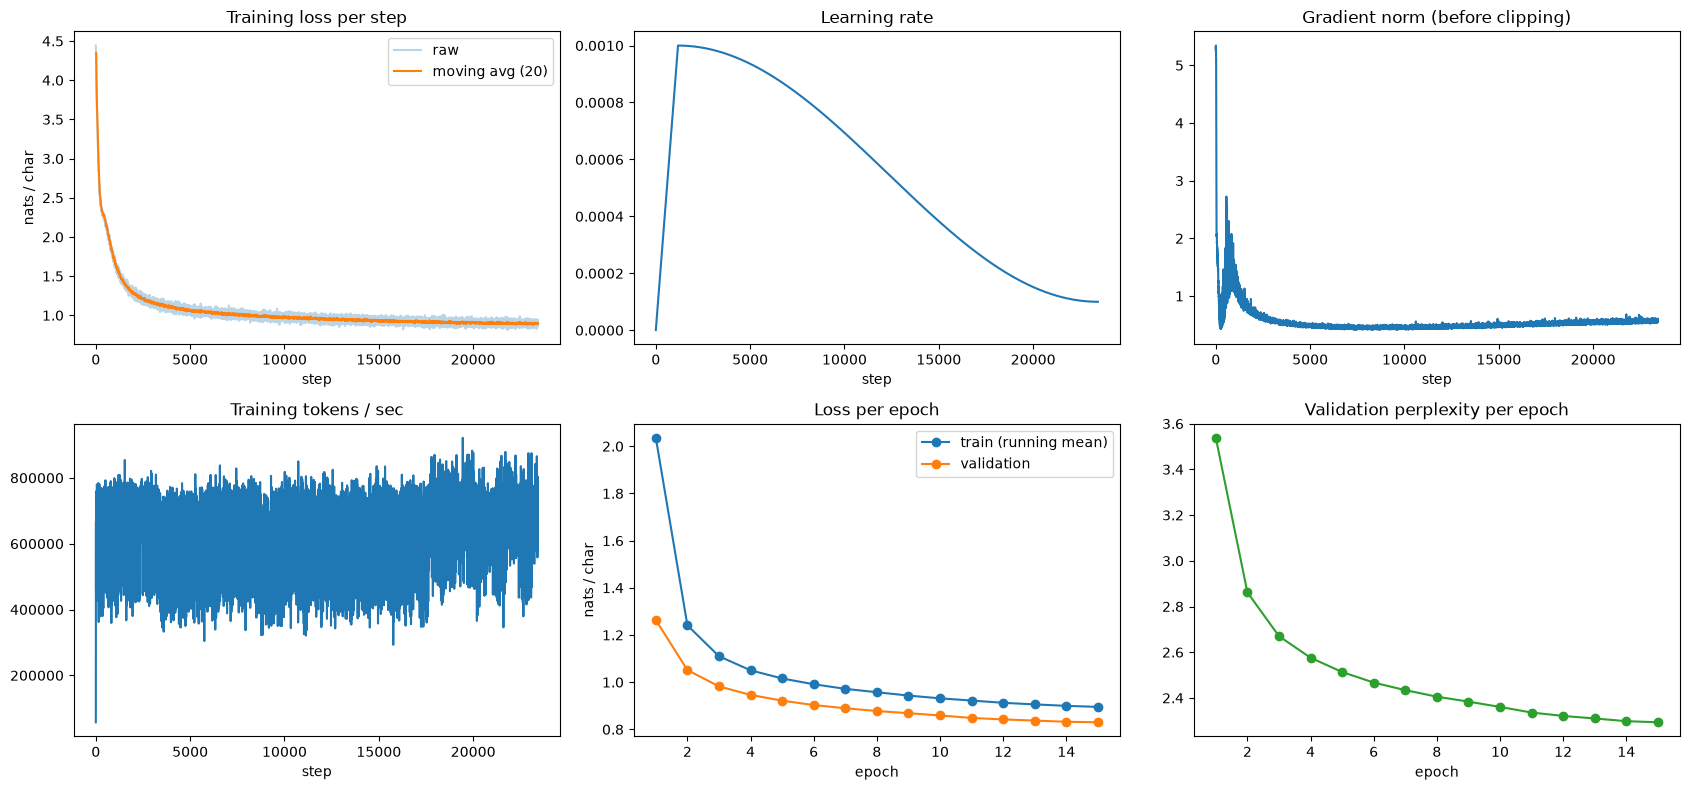

saved ..\outputs\main_loss_curves.png


In [8]:
def read_rows(path):
    with open(path, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


def smooth(x, y, window):
    """Moving average that stays aligned with x."""
    window = max(1, min(window, len(y)))
    kernel = np.ones(window) / window
    return x[window - 1:], np.convolve(y, kernel, mode="valid")


def plot_training_curves(step_path, epoch_path, out_path, smooth_window):
    steps = read_rows(step_path)
    epochs = read_rows(epoch_path)
    s = np.array([int(r["step"]) for r in steps])
    loss = np.array([float(r["loss"]) for r in steps])
    lr = np.array([float(r["lr"]) for r in steps])
    gnorm = np.array([float(r["grad_norm"]) for r in steps])
    tps = np.array([float(r["tokens_per_sec"]) for r in steps])
    e = np.array([int(r["epoch"]) for r in epochs])
    e_train = np.array([float(r["train_loss"]) for r in epochs])
    e_val = np.array([float(r["val_loss"]) for r in epochs])
    e_ppl = np.array([float(r["val_perplexity"]) for r in epochs])

    fig, axes = plt.subplots(2, 3, figsize=(17, 8))

    ax = axes[0, 0]
    ax.plot(s, loss, alpha=0.3, label="raw")
    sx, sy = smooth(s, loss, smooth_window)
    ax.plot(sx, sy, label=f"moving avg ({smooth_window})")
    ax.set_title("Training loss per step")
    ax.set_xlabel("step")
    ax.set_ylabel("nats / char")
    ax.legend()

    axes[0, 1].plot(s, lr)
    axes[0, 1].set_title("Learning rate")
    axes[0, 1].set_xlabel("step")

    axes[0, 2].plot(s, gnorm)
    axes[0, 2].set_title("Gradient norm (before clipping)")
    axes[0, 2].set_xlabel("step")

    axes[1, 0].plot(s, tps)
    axes[1, 0].set_title("Training tokens / sec")
    axes[1, 0].set_xlabel("step")

    axes[1, 1].plot(e, e_train, marker="o", label="train (running mean)")
    axes[1, 1].plot(e, e_val, marker="o", label="validation")
    axes[1, 1].set_title("Loss per epoch")
    axes[1, 1].set_xlabel("epoch")
    axes[1, 1].set_ylabel("nats / char")
    axes[1, 1].legend()

    axes[1, 2].plot(e, e_ppl, marker="o", color="tab:green")
    axes[1, 2].set_title("Validation perplexity per epoch")
    axes[1, 2].set_xlabel("epoch")

    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


train_summary = train_model(cfg)
print(json.dumps(train_summary, indent=1))

CURVES_PATH = P["output_dir"] / f"{RUN_NAME}_loss_curves.png"
plot_training_curves(STEP_LOG_PATH, EPOCH_LOG_PATH, CURVES_PATH, cfg["plots"]["smooth_window"])
print("saved", CURVES_PATH)

## 5) Evaluation and `metrics_report.csv`

This cell loads the checkpoint chosen in `eval.checkpoint` (best by default) and measures it on **fixed
windows**, so every run is compared in exactly the same way. All the loss-based numbers come from one
cross-entropy:

| Metric | How I compute it |
|---|---|
| Val loss | mean cross-entropy (nats per character) on the fixed validation windows |
| Perplexity | `exp(val_loss)` |
| Bits per character | `val_loss / ln 2` |
| Train loss | the same measurement on fixed training windows, in eval mode (dropout off) |
| Generalization gap | `val_loss - train_loss` |
| Top-1 accuracy | `argmax(logits) == y`, averaged over all positions |
| Parameters | sum of `numel` over the parameters (a tied weight is counted once) |
| Train tokens/sec, peak memory, total time, non-finite steps, max grad norm | read from the run summary that training wrote |

The generation-based metrics (Distinct-1/2/3, repeated 4-gram rate, generation tokens/sec) need
generated text, so they are computed in section 6 and written to the same CSV. The CSV has one row per
`(metric, setting)` pair. Writing a row again replaces the old value and leaves other rows alone, so I can
rerun either section without losing the other half.

In [9]:
METRIC_FIELDS = ["metric", "setting", "value", "notes"]


def metric_row(metric, value, setting="all", notes=""):
    if isinstance(value, float):
        value = f"{value:.8g}"
    return {"metric": metric, "setting": setting, "value": value, "notes": notes}


def update_metrics_report(path, rows):
    """Insert or replace rows keyed by (metric, setting); other rows are kept."""
    path = Path(path)
    merged = {}
    if path.exists():
        with open(path, newline="", encoding="utf-8") as f:
            for r in csv.DictReader(f):
                merged[(r["metric"], r["setting"])] = r
    for r in rows:
        merged[(r["metric"], r["setting"])] = {k: r.get(k, "") for k in METRIC_FIELDS}
    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=METRIC_FIELDS)
        writer.writeheader()
        writer.writerows(merged.values())


def load_model_from_checkpoint(path):
    ck = torch_load(path)
    if ck["chars"] != chars:
        raise ValueError("The checkpoint vocabulary does not match the current data. Rebuild the data with the same config.")
    model = build_model(cfg, vocab_size).to(device)
    model.load_state_dict(ck["model"])
    model.eval()
    return model, ck


def run_evaluation(cfg):
    ecfg = cfg["eval"]
    ckpt_path = CKPT[ecfg["checkpoint"]]
    model, ck = load_model_from_checkpoint(ckpt_path)

    val = evaluate_windows(model, val_X, val_Y, ecfg["batch_size"])
    trn = evaluate_windows(model, train_eval_X, train_eval_Y, ecfg["batch_size"])

    run_summary = {}
    if SUMMARY_PATH.exists():
        with open(SUMMARY_PATH, "r", encoding="utf-8") as f:
            run_summary = json.load(f)
    nan = float("nan")

    rows = [
        metric_row("val_loss", val["loss"], notes="nats per character, fixed validation windows"),
        metric_row("val_perplexity", math.exp(val["loss"]), notes="exp(val_loss)"),
        metric_row("val_bpc", val["loss"] / LN2, notes="val_loss / ln 2"),
        metric_row("train_loss_eval_mode", trn["loss"], notes="fixed train windows, dropout off"),
        metric_row("generalization_gap", val["loss"] - trn["loss"], notes="val_loss - train_loss"),
        metric_row("val_top1_accuracy", val["acc"], notes="argmax(logits) == target"),
        metric_row("train_top1_accuracy", trn["acc"], notes="fixed train windows, dropout off"),
        metric_row("param_count", count_params(model)),
        metric_row("train_tokens_per_sec", float(run_summary.get("train_tokens_per_sec_mean", nan)),
                   notes="mean over training steps"),
        metric_row("peak_gpu_memory_mb", float(run_summary.get("peak_memory_mb", nan)),
                   notes="torch.cuda.max_memory_allocated; 0 on a CPU run"),
        metric_row("total_train_time_sec", float(run_summary.get("total_train_time_sec", nan)),
                   notes="wall clock, includes per-epoch validation"),
        metric_row("nonfinite_steps", run_summary.get("nonfinite_steps", ""),
                   notes="steps with NaN/inf loss or grad norm"),
        metric_row("max_grad_norm", float(run_summary.get("max_grad_norm", nan)),
                   notes="largest finite grad norm before clipping"),
        metric_row("best_epoch", run_summary.get("best_epoch", "")),
        metric_row("epochs_completed", run_summary.get("epochs_completed", "")),
        metric_row("checkpoint_evaluated", ecfg["checkpoint"], notes=f"saved at epoch {ck['epoch']}"),
        metric_row("split_unit", cfg["data"]["split_unit"],
                   notes=f"train_size={cfg['data']['train_size']}, val_size={cfg['data']['val_size']}"),
        metric_row("vocab_size", vocab_size),
    ]
    update_metrics_report(P["metrics_csv"], rows)

    for r in rows:
        print(f"{r['metric']:<24} {str(r['value']):>14}   {r['notes']}")
    print("\nwritten to", P["metrics_csv"])
    return model, rows


eval_model, eval_rows = run_evaluation(cfg)

val_loss                     0.83012515   nats per character, fixed validation windows
val_perplexity                2.2936058   exp(val_loss)
val_bpc                       1.1976174   val_loss / ln 2
train_loss_eval_mode         0.80998349   fixed train windows, dropout off
generalization_gap          0.020141658   val_loss - train_loss
val_top1_accuracy            0.73917344   argmax(logits) == target
train_top1_accuracy          0.74379297   fixed train windows, dropout off
param_count                      830976   
train_tokens_per_sec          649526.16   mean over training steps
peak_gpu_memory_mb            324.36914   torch.cuda.max_memory_allocated; 0 on a CPU run
total_train_time_sec          303.23195   wall clock, includes per-epoch validation
nonfinite_steps                       6   steps with NaN/inf loss or grad norm
max_grad_norm                   5.34267   largest finite grad norm before clipping
best_epoch                           15   
epochs_completed             

## 6) Generation

This cell generates text one character at a time from **5 fixed prompts** (listed in the config) using
several decoding settings:

- **Greedy:** always take the most likely next character. It is deterministic, which makes
  repetition failures easy to see.
- **Temperature sampling:** divide the logits by the temperature before the softmax and sample. Below 1
  sharpens the distribution, above 1 flattens it. The config has 0.7, 1.0 and 1.2.
- **Top-k (optional):** before sampling, keep only the `k` most likely characters. The config repeats
  each temperature with `top_k = 40`.

At every step the context is cropped to the last `block_size` characters. For the prompt with index
`i` the sampling generator is seeded with `SEED + i`, so every run and every setting uses the same
seeds and results compare directly.

For each setting I save the samples to `outputs/<run>_samples/<setting>.txt` (plus one JSON file with
everything), and I compute the text-diversity metrics on the generated continuation only (the prompt is
excluded), averaged over the prompts:

- **Distinct-n** (n = 1, 2, 3): unique n-grams divided by total n-grams. Low means repetitive.
- **Repeated 4-gram rate:** the fraction of 4-gram positions whose 4-gram occurs more than once.
- **Generation tokens/sec:** new characters divided by generation time (batch size 1).

The n-gram unit (`chars` or `words`) is set in the config. All of these rows are written into
`metrics_report.csv` next to the loss-based metrics.

In [10]:
gcfg = cfg["generation"]


def ngram_stats(tokens, n):
    """Returns (distinct-n, repeated-n-gram rate) for a token list."""
    grams = [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]
    if not grams:
        return float("nan"), float("nan")
    counts = Counter(grams)
    distinct = len(counts) / len(grams)
    repeated = sum(c for c in counts.values() if c > 1) / len(grams)
    return distinct, repeated


def diversity_metrics(text, unit):
    if unit == "chars":
        tokens = list(text)
    elif unit == "words":
        tokens = text.split()
    else:
        raise ValueError(f"ngram_unit must be 'chars' or 'words', got {unit!r}")
    return {
        "distinct_1": ngram_stats(tokens, 1)[0],
        "distinct_2": ngram_stats(tokens, 2)[0],
        "distinct_3": ngram_stats(tokens, 3)[0],
        "repeated_4gram_rate": ngram_stats(tokens, 4)[1],
    }


def run_generation(model, gcfg):
    sample_dir = P["output_dir"] / f"{RUN_NAME}_samples"
    sample_dir.mkdir(parents=True, exist_ok=True)
    unit = gcfg["ngram_unit"]
    n_prompts = len(gcfg["prompts"])
    results, metric_rows = {}, []

    for setting in gcfg["settings"]:
        name = setting["name"]
        greedy = bool(setting.get("greedy", False))
        temperature = setting.get("temperature")
        top_k = setting.get("top_k")
        if not greedy and temperature is None:
            raise ValueError(f"Setting {name!r} needs either greedy: true or a temperature")

        per_prompt, gen_time, gen_tokens = [], 0.0, 0
        for i, prompt in enumerate(gcfg["prompts"]):
            generator = torch.Generator(device=device)
            generator.manual_seed(SEED + i)
            idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

            sync()
            t0 = time.perf_counter()
            out = model.generate(idx, gcfg["max_new_tokens"], temperature=temperature, top_k=top_k,
                                 greedy=greedy, generator=generator)
            sync()
            gen_time += time.perf_counter() - t0
            gen_tokens += gcfg["max_new_tokens"]

            continuation = decode(out[0, idx.size(1):].tolist())
            per_prompt.append({"prompt": prompt, "continuation": continuation,
                               **diversity_metrics(continuation, unit)})

        averages = {key: float(np.mean([item[key] for item in per_prompt]))
                    for key in ("distinct_1", "distinct_2", "distinct_3", "repeated_4gram_rate")}
        tokens_per_sec = gen_tokens / max(gen_time, 1e-12)

        lines = [f"setting: {name} | greedy={greedy} temperature={temperature} top_k={top_k} | seed base {SEED}", ""]
        for i, item in enumerate(per_prompt):
            lines += [f"=== prompt {i + 1}: {item['prompt']!r} ===", item["prompt"] + item["continuation"], ""]
        (sample_dir / f"{name}.txt").write_text("\n".join(lines), encoding="utf-8")

        results[name] = {"greedy": greedy, "temperature": temperature, "top_k": top_k,
                         "samples": per_prompt, "mean_metrics": averages,
                         "generation_tokens_per_sec": tokens_per_sec}
        note = f"mean over {n_prompts} prompts, {unit}-grams of the continuation"
        for key, value in averages.items():
            metric_rows.append(metric_row(key, value, setting=name, notes=note))
        metric_rows.append(metric_row("generation_tokens_per_sec", tokens_per_sec, setting=name,
                                      notes="new characters / generation time, batch size 1"))

        print(f"[{name}] distinct-1 {averages['distinct_1']:.3f} | distinct-2 {averages['distinct_2']:.3f} "
              f"| distinct-3 {averages['distinct_3']:.3f} | repeated 4-gram rate {averages['repeated_4gram_rate']:.3f} "
              f"| {tokens_per_sec:,.0f} tok/s")
        preview = per_prompt[0]
        print("   preview (prompt 1):", repr((preview["prompt"] + preview["continuation"])[:300]))

    with open(P["output_dir"] / f"{RUN_NAME}_samples.json", "w", encoding="utf-8") as f:
        json.dump(results, f, indent=1, ensure_ascii=False)
    update_metrics_report(P["metrics_csv"], metric_rows)
    print("\nsamples saved in", sample_dir, "| metrics updated in", P["metrics_csv"])
    return results


generation_results = run_generation(eval_model, gcfg)

[greedy] distinct-1 0.324 | distinct-2 0.449 | distinct-3 0.498 | repeated 4-gram rate 0.599 | 331 tok/s
   preview (prompt 1): 'Once upon a time, there was a little girl named Lily. She loved to play with her friends. One day, she was playing with her friends. She wanted to play with her friends. She saw a big box on the ground. She wanted to play with her friends.\nThe boy said, "I will help you find your friends." The boy w'


[temp_0.7] distinct-1 0.634 | distinct-2 0.893 | distinct-3 0.958 | repeated 4-gram rate 0.047 | 320 tok/s
   preview (prompt 1): 'Once upon a time, there was a little girl named Lily who was made a big park. She had a big ball and danced together every day, the ball would be happy with a big ball. The ball was the match and wanted to wear the park to play with his friends.\nOne day, a little ball wanted to share with his mom. T'


[temp_1.0] distinct-1 0.713 | distinct-2 0.958 | distinct-3 0.985 | repeated 4-gram rate 0.017 | 330 tok/s
   preview (prompt 1): 'Once upon a time, there was a xect. They were sad busy. Whire they were playing, they went home, and dary asked for help as her they enjoyed the worm. They played with the sunflower together.\nThey all became best friends, together. They played with their holes and played all day. And when they finis'


[temp_1.2] distinct-1 0.783 | distinct-2 0.982 | distinct-3 0.996 | repeated 4-gram rate 0.000 | 323 tok/s
   preview (prompt 1): 'Once upon a time, there was a xect. They were sad busy. Whirl they were playing, they went home, and dary on, time they had a big kind and a nuts. One sunny day, Lily found a flower to the bubble. He wanted to lead a big, toast wish liked.\n"Come we go invite my raft towards?" her mom was an uolcause'


[temp_0.7_topk40] distinct-1 0.634 | distinct-2 0.893 | distinct-3 0.958 | repeated 4-gram rate 0.047 | 353 tok/s
   preview (prompt 1): 'Once upon a time, there was a little girl named Lily who was made a big park. She had a big ball and danced together every day, the ball would be happy with a big ball. The ball was the match and wanted to wear the park to play with his friends.\nOne day, a little ball wanted to share with his mom. T'


[temp_1.0_topk40] distinct-1 0.713 | distinct-2 0.958 | distinct-3 0.985 | repeated 4-gram rate 0.017 | 354 tok/s
   preview (prompt 1): 'Once upon a time, there was a xect. They were sad busy. Whire they were playing, they went home, and dary asked for help as her they enjoyed the worm. They played with the sunflower together.\nThey all became best friends, together. They played with their holes and played all day. And when they finis'


[temp_1.2_topk40] distinct-1 0.783 | distinct-2 0.982 | distinct-3 0.996 | repeated 4-gram rate 0.000 | 357 tok/s
   preview (prompt 1): 'Once upon a time, there was a xect. They were sad busy. Whirl they were playing, they went home, and dary on, time they had a big kind and a nuts. One sunny day, Lily found a flower to the bubble. He wanted to lead a big, toast wish liked.\n"Come we go invite my raft towards?" her mom was an uolcause'

samples saved in ..\outputs\main_samples | metrics updated in ..\metrics_report.csv


## Failure analysis

See `../failure_analysis.md`: three failure cases quoted from `../outputs/main_samples/`.

## Results and design justification

See `../results.md`: setup, hyperparameters, metrics, ablations, stability and limitations.